In [ ]:
import tkinter as tk
from tkinter import ttk
from tkinter import filedialog
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def select_directory(root, close=True):
    """
    Opens a directory selection dialog and returns the selected path
    
    Args:
        root: Tkinter root window
        close: Close the root window after selection (default: True)
        
    Returns:
        str: Selected directory path or empty string if cancelled
    """
    directory = filedialog.askdirectory(
        parent=root,
        initialdir=".",
        title="Select Directory"
    )
    if close:
        root.destroy()
    return directory

def select_files(root, close=True):
    """
    Opens a file selection dialog and returns the selected paths
    
    Args:
        root: Tkinter root window
        close: Close the root window after selection (default: True)
        
    Returns:
        list: Selected file paths or empty list if cancelled
    """
    files = filedialog.askopenfilenames(
        parent=root,
        initialdir=".",
        title="Select Files",
        filetypes=(("All files", "*.*"),)
    )
    if close:
        root.destroy()
    return files

def getdir():
    root = tk.Tk()
    return select_directory(root, close=True)

def getfiles():
    root = tk.Tk()
    return select_files(root, close=True)

# loadclaraimage function from deflib1
def loadclaraimage(file):
    with open(file) as f:
        for i in range(34):
            f.readline()
        fload = f.readlines()
    x = []
    y = []
    data = []
    for i in fload:
        isplit = i.split('\n')[0].split('\t')
        x.append(float(isplit[0]))
        for j in range(1, len(isplit)):
            if isplit[j] == '':
                pass
            else:
                y.append(float(isplit[j]))
        data.append(y)
        y = []  
    return np.asarray(data)


In [3]:
d = getdir() # open dir # run this cell to open a dir and save it on d
print(d)

C:/Users/volib/Desktop/Evaluation/data/2024/qdot_100fach/Laser_in_zpos


In [ ]:
f = getfiles() # open files # run this cell to open files and save them to the array f
# example: f = C:\Users\volib\Desktop\Evaluation\data\2024\qdot_100fach\Laser_in_zpos
print(len(f), f)
if len(f) == 1:
    f = f[0]
    print(f)

1 ('C:/Users/volib/Desktop/Evaluation/data/2024/qdot_100fach/Laser_in_zpos/146_0.asc',)


In [9]:
# test if the dialog is working properly
print(d)
print(f)

C:/Users/volib/Desktop/Evaluation/data/2024/qdot_100fach/Laser_in_zpos
C:/Users/volib/Desktop/Evaluation/data/2024/qdot_100fach/Laser_in_zpos/146_0.asc


C:/Users/volib/Desktop/Evaluation/data/2024/qdot_100fach/Laser_in_zpos/146_0.asc


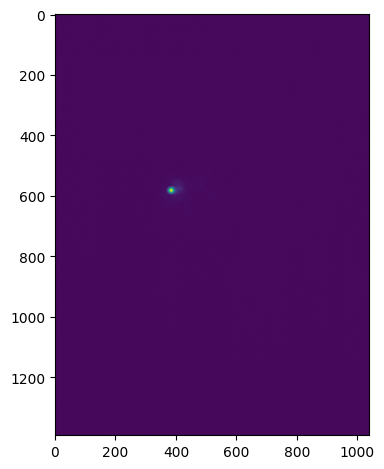

c:\Users\volib\Desktop\Evaluation\code\SpecMap\SpecMap1\openerJN\claralib2.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


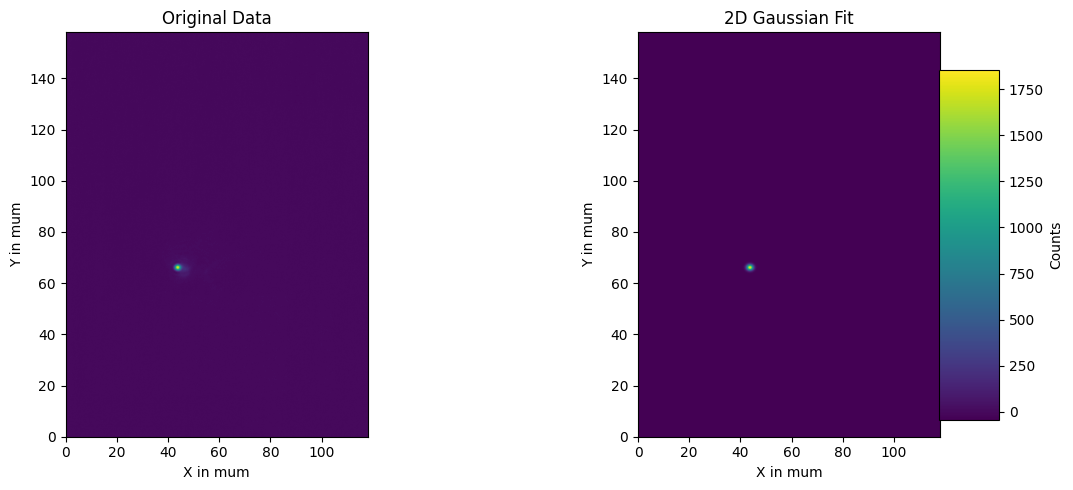

fit widht x and y: 1.9247350595177117 1.6569701570287378 dx and dy: 0.1136 0.1136 x0, y0: 43.60030192558743 66.16016565566743 xsize, ysize: 1.9247350595177117 1.6569701570287378 xbelowthresh, ybelowthresh: 47.449772044622854 69.4741059697249
Area of ellipse: 10.019


In [11]:
# add code to process the selected files or directory
import claralib2 as cl

# create tkinter window
root = tk.Tk()
root.geometry('{}x{}'.format(800, 600))
frame = ttk.Frame(root)
# create nodeframes
nodeframes = {}
# create notebook with title "Clara1"
notebook = ttk.Notebook(frame)
notebook.pack(fill="both", expand=True)
nodeframes["Clara1"] = ttk.Frame(notebook)
notebook.add(nodeframes["Clara1"], text="Clara1")
# pack the clara1 frame
frame.pack(fill="both", expand=True)

dx = dx = 0.0568*2#0.0568 
dy = 0.0568*2#0.0568


# create clara processing frame
imp = cl.imageprocessor(nodeframes["Clara1"], f, cl.loadclaraimage, None, dx, dy)


root.mainloop()